## Notebook 04: **Multi-Window Global Signal Analysis**

## Purpose of This Notebook

This notebook extends the proxy analysis from a single-window setting to a **multi-window temporal evaluation**.

Notebook 03 established a shortlist of stable proxy variants based on:

- distribution behavior,
- numerical stability,
- and range dependence.

However, those conclusions were drawn from a single representative window.

This notebook asks the next critical question:

> Do these proxy signals behave consistently across different temporal segments of the sequence?

---

## Why This Notebook Exists

The preliminary stage and Notebook 03 demonstrated that proxy transformations such as:

$$
\phi(I, R) = I \cdot R,\quad \log(1 + I \cdot R)
$$

can produce meaningful signal restructuring.

But a single window is not sufficient for robust conclusions.

The final project requires:

- evaluation across multiple windows,
- coverage across different parts of the sequence,
- and aggregation of behavior across varying scene conditions.

Without this step, the analysis risks being:

- overly local,
- sensitive to favorable segments,
- and not representative of full-sequence behavior.

## Core Idea

We now treat the dataset as a collection of windows:

$$
\mathcal{W} = \{W_1, W_2, \dots, W_K\}
$$

Each window $W_k$ contains a sequence of frames:

$$
W_k = \{f_{s_k}, f_{s_k+1}, \dots, f_{s_k + L - 1}\}
$$

For each window, we compute signal statistics for each proxy:

$$
\phi_j(I, R)
$$

This produces per-window summaries:

$$
M_{k,j} = M(\phi_j \mid W_k)
$$

where $M$ includes metrics such as:

- mean,
- standard deviation,
- percentiles,
- range correlation.

The goal is to analyze the distribution:

$$
\{M_{k,j}\}_{k=1}^K
$$

instead of relying on a single instance.

## Mathematical Framework

### 1. Signals

For each point $i$ in window $W_k$:

$$
I_i, \quad R_i = \sqrt{x_i^2 + y_i^2 + z_i^2}
$$

Proxy variants:

$$
\phi_0 = I
$$

$$
\phi_1 = I \cdot R
$$

$$
\phi_2 = \log(1 + I \cdot R)
$$

$$
\phi_3 = \text{normalized}(I \cdot R)
$$

### 2. Window-wise Metrics

For each window $W_k$ and proxy $\phi_j$:

#### Mean

$$
\mu_{k,j} = \frac{1}{N_k} \sum_{i \in W_k} \phi_j(i)
$$

#### Spread (standard deviation)

$$
\sigma_{k,j} = \sqrt{\frac{1}{N_k} \sum (\phi_j(i) - \mu_{k,j})^2}
$$

#### Percentiles

$$
p_{q,k,j} = \text{percentile}_q(\phi_j \mid W_k)
$$

#### Range correlation

$$
\rho_{k,j} = \text{corr}(\phi_j, R)
$$

### 3. Temporal Stability

We evaluate how stable each proxy is across windows:

#### Mean variation

$$
\text{Var}_k(\mu_{k,j})
$$

#### Coefficient of variation

$$
CV_j = \frac{\text{std}_k(\mu_{k,j})}{\text{mean}_k(\mu_{k,j}) + \epsilon}
$$

Interpretation:
- low CV → stable proxy.  
- high CV → unstable across scenes.

## Core Questions This Notebook Answers

This notebook focuses on **global signal behavior across time**, not semantics.

### 1. Stability
- Do proxy statistics remain consistent across windows?
- Does the signal drift significantly?

### 2. Range Dependence Across Windows
- Is correlation stable across windows?
- Are there windows where the proxy becomes range-dominated?

### 3. Distribution Consistency
- Do percentiles shift significantly across windows?
- Is the signal well-behaved across different scenes?

### 4. Proxy Comparison
- Which proxy is:
  - most stable?
  - most consistent?
  - least sensitive to scene variation?

## What This Notebook Will Do

Step-by-step:

1. Load window metadata from Notebook 02.
2. Iterate over all selected windows.
3. For each window:
   - load frames.
   - compute $I, R$.
   - construct selected proxy variants.
4. Compute per-window metrics.
5. Build a global metrics table.
6. Visualize:
   - temporal trends,
   - variability across windows.
7. Compare proxies at a global level.

## What This Notebook Is Not Allowed to Do

This notebook still does not perform semantic analysis.

It must not:

- compute class-wise metrics,
- claim semantic improvement,
- identify best/worst classes,
- perform failure-case analysis,
- generate videos or GIFs,
- make downstream task claims.

Those belong to later notebooks.

This notebook is strictly:

> **global signal behavior analysis across multiple windows**

## Expected Outputs

By the end of this notebook, we should have:

- per-window summary tables,
- temporal plots of signal statistics,
- stability metrics (mean, variance, CV),
- range correlation trends across windows,
- comparison across proxy variants.

## Expected Outcomes

If the proxies are well-designed, we expect:

- moderate variation in mean and spread,
- stable percentile structure,
- consistent range correlation across windows,
- no extreme instability in any window.

We also expect:

- log-scaled proxy to show improved stability,
- normalized variants to improve comparability,
- raw intensity to remain compressed and less expressive.

## Core Honesty Statement

This notebook evaluates signal behavior, not semantic performance.

Even if a proxy is stable:

- it is not necessarily semantically superior,
- it remains a heuristic transformation,
- and still depends on scene composition and range.

## Final Takeaway of This Notebook

If this notebook succeeds, we will have:

> a set of proxy signals that are not only numerically stable in one window, but consistently well-behaved across multiple temporal segments.

This establishes a strong foundation for:

**multi-window semantic analysis in the next stage.**

---

## Load Window Metadata and Initialize Analysis Pipeline

We begin by loading the multi-window structure defined in Notebook 02.

Unlike Notebook 03, which operated on a single window,
this notebook will iterate over **all selected windows**.

From the metadata, we recover:

- window identifiers,
- start and end indices,
- window lengths,
- temporal coverage across the sequence.

We will use this metadata to:

- systematically load each window,
- compute signal statistics per window,
- and aggregate results across windows.

At this stage, we do not yet compute any proxy signals.

We only:

- load the metadata,
- inspect its structure,
- and prepare the iteration framework.

This ensures that all further analysis is:

- reproducible,
- consistent,
- and aligned with the validated temporal structure.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

# Step 0: Resolve dataset root
candidate_roots = [
    Path("../data/semantickitti_subset/dataset/sequences/00"),
    Path("../data/semantickitti/dataset/sequences/00"),
]

DATASET_ROOT = next((p for p in candidate_roots if p.exists()), candidate_roots[0])

print("Dataset Root:", DATASET_ROOT.resolve())
print("Exists:", DATASET_ROOT.exists())

# Step 1: Load window metadata
metadata_path = Path("../results/window_metadata/sequence00_windows.csv")
window_df = pd.read_csv(metadata_path)

print("\nLoaded Window Metadata")
print()
print("Shape:", window_df.shape)

# Inspect structure
print("\nColumns:", list(window_df.columns))

print("\nFirst few rows:")
print(window_df.head())

# Step 2: Basic sanity checks
assert len(window_df) > 0, "No windows found"
assert {"window_id", "scale", "start_idx", "end_idx", "length"}.issubset(window_df.columns)

print("\nMetadata sanity check passed.")

# Step 3: Prepare frame index (shared across all windows)
velodyne_dir = DATASET_ROOT / "velodyne"
FRAME_IDS = sorted([f.stem for f in velodyne_dir.glob("*.bin")])

print("\nGlobal Frame Info")
print()
print("Total frames:", len(FRAME_IDS))
print("First frame :", FRAME_IDS[0])
print("Last frame  :", FRAME_IDS[-1])

Dataset Root: /home/twilightpriest/GitHub/reflect-aug-seg/data/semantickitti/dataset/sequences/00
Exists: True

Loaded Window Metadata

Shape: (15, 7)

Columns: ['window_id', 'scale', 'start_idx', 'end_idx', 'length', 'first_frame', 'last_frame']

First few rows:
  window_id  scale  start_idx  end_idx  length  first_frame  last_frame
0   short_0  short          0        9      10            0           9
1   short_1  short       1132     1141      10         1132        1141
2   short_2  short       2265     2274      10         2265        2274
3   short_3  short       3398     3407      10         3398        3407
4   short_4  short       4531     4540      10         4531        4540

Metadata sanity check passed.

Global Frame Info

Total frames: 4541
First frame : 000000
Last frame  : 004540


## Iterate Over Windows and Compute Base Signals

We now construct the core analysis loop over all windows.

For each window $W_k$, we:

1. reconstruct the list of frame IDs using:
   $$
   f_t \in [\text{start\_idx}, \text{end\_idx}]
   $$

2. load all LiDAR frames in the window,

3. extract:
   - coordinates $(x, y, z)$,
   - raw intensity $I$,

4. compute geometric range:
   $$
   R = \sqrt{x^2 + y^2 + z^2}
   $$

This gives us the base signals:

$$
I, \quad R
$$

for each window.

We do not compute proxy variants yet.

The goal is to:

- establish a clean per-window data pipeline,
- verify consistency across windows,
- and prepare for metric computation in the next step.

This loop is the foundation of all multi-window analysis.

In [3]:
# Initialize storage
window_data = []

velodyne_dir = DATASET_ROOT / "velodyne"

print("Processing Windows")
print()

for idx, row in window_df.iterrows():
    
    start_idx = int(row["start_idx"])
    end_idx = int(row["end_idx"])
    length = int(row["length"])
    
    # Reconstruct frame IDs
    frame_ids = FRAME_IDS[start_idx:end_idx + 1]
    
    assert len(frame_ids) == length, f"Window length mismatch at index {idx}"
    
    all_xyz = []
    all_intensity = []
    
    # Load frames
    for fid in frame_ids:
        bin_path = velodyne_dir / f"{fid}.bin"
        
        scan = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)
        
        xyz_part = scan[:, :3]
        intensity_part = scan[:, 3]
        
        all_xyz.append(xyz_part)
        all_intensity.append(intensity_part)
    
    # Concatenate
    xyz = np.concatenate(all_xyz, axis=0)
    intensity = np.concatenate(all_intensity, axis=0)
    
    # Compute range
    ranges = np.linalg.norm(xyz, axis=1)
    
    # Store
    window_data.append({
        "window_id": row["window_id"],
        "scale": row["scale"],
        "num_points": xyz.shape[0],
        "I": intensity,
        "R": ranges
    })
    
    print(f"Processed {row['window_id']} | points: {xyz.shape[0]}")

print("\nAll windows processed successfully.")
print("Total windows:", len(window_data))

Processing Windows

Processed short_0 | points: 1235429
Processed short_1 | points: 1242631
Processed short_2 | points: 1238010
Processed short_3 | points: 1234193
Processed short_4 | points: 1219048
Processed medium_0 | points: 3697281
Processed medium_1 | points: 3732529
Processed medium_2 | points: 3710748
Processed medium_3 | points: 3703948
Processed medium_4 | points: 3618022
Processed long_0 | points: 12131091
Processed long_1 | points: 12491825
Processed long_2 | points: 12361569
Processed long_3 | points: 12386545
Processed long_4 | points: 12171675

All windows processed successfully.
Total windows: 15


## Compute Per-Window Signal Metrics

We now compute summary statistics for each window and each proxy.

For each window $W_k$, we evaluate:

- raw intensity $I$,
- primary proxy $I \cdot R$,
- log-scaled proxy $\log(1 + I \cdot R)$.

For each signal, we compute:

### Mean
    
$$
\mu_k = \text{mean}(\phi)
$$

### Standard deviation

$$
\sigma_k = \text{std}(\phi)
$$

### Upper percentile (p95)

$$
p95_k = \text{percentile}_{95}(\phi)
$$

### Range correlation

$$
\rho_k = \text{corr}(\phi, R)
$$

These metrics allow us to analyze:

- how signals shift across windows,
- how stable each proxy is,
- and whether behavior is consistent across the sequence.

This is the first step toward global signal comparison.

In [4]:
metrics = []

print("Computing Window Metrics")
print()

for wd in window_data:
    
    I = wd["I"]
    R = wd["R"]
    
    # Proxies
    phi_I = I
    phi_IR = I * R
    phi_log_IR = np.log1p(phi_IR)
    
    def compute_stats(values, R):
        return {
            "mean": float(np.mean(values)),
            "std": float(np.std(values)),
            "p95": float(np.percentile(values, 95)),
            "corr_range": float(np.corrcoef(values, R)[0, 1])
        }
    
    row = {
        "window_id": wd["window_id"],
        "scale": wd["scale"]
    }
    
    # Compute metrics for each proxy
    stats_I = compute_stats(phi_I, R)
    stats_IR = compute_stats(phi_IR, R)
    stats_log = compute_stats(phi_log_IR, R)
    
    # Flatten
    for key, val in stats_I.items():
        row[f"I_{key}"] = val
        
    for key, val in stats_IR.items():
        row[f"IR_{key}"] = val
        
    for key, val in stats_log.items():
        row[f"logIR_{key}"] = val
    
    metrics.append(row)
    
    print(f"Processed metrics for {wd['window_id']}")

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics)

print("\nMetrics Table Shape:", metrics_df.shape)
print("\nPreview:")
print(metrics_df.head())

Computing Window Metrics

Processed metrics for short_0
Processed metrics for short_1
Processed metrics for short_2
Processed metrics for short_3
Processed metrics for short_4
Processed metrics for medium_0
Processed metrics for medium_1
Processed metrics for medium_2
Processed metrics for medium_3
Processed metrics for medium_4
Processed metrics for long_0
Processed metrics for long_1
Processed metrics for long_2
Processed metrics for long_3
Processed metrics for long_4

Metrics Table Shape: (15, 14)

Preview:
  window_id  scale    I_mean     I_std  I_p95  I_corr_range   IR_mean  \
0   short_0  short  0.295958  0.153738   0.55     -0.209008  3.580216   
1   short_1  short  0.306943  0.150780   0.55     -0.177154  3.697625   
2   short_2  short  0.285901  0.144584   0.52     -0.138244  3.415892   
3   short_3  short  0.303594  0.139117   0.52     -0.107284  3.155725   
4   short_4  short  0.277612  0.150195   0.51     -0.111203  3.400961   

     IR_std    IR_p95  IR_corr_range  logIR_

## Interpretation: Per-Window Signal Metrics

We computed summary statistics for each window and each proxy, producing a table of per-window metrics.

### 1. Raw Intensity $I$

Across windows:

- mean remains within a narrow band (~0.27–0.31),
- standard deviation remains stable (~0.14–0.15),
- range correlation remains weak and negative.

This confirms that raw intensity is:

- numerically stable across windows,
- weakly dependent on range,
- but limited in dynamic range and expressiveness.

### 2. Primary Proxy $I \cdot R$

Across windows:

- mean and standard deviation are moderately stable,
- percentile values remain consistent,
- range correlation typically lies in the moderate range (~0.35–0.45).

However, certain windows show elevated correlation:

$$
\rho \approx 0.57 \text{ in some cases}
$$

This indicates:

- window-dependent behavior,
- occasional dominance of range in specific segments,
- sensitivity to scene composition.

### 3. Log-Scaled Proxy $\log(1 + I \cdot R)$

Across windows:

- mean and spread remain tightly controlled,
- distribution is stable across windows,
- range correlation is consistently lower than $I \cdot R$,
  but still exhibits variation across windows.

Even with log scaling, certain windows show increased correlation,
indicating that:

- log transformation improves stability,
- but does not eliminate window-dependent effects.

### 4. Key Observations

This table reveals an important transition from single-window to multi-window behavior:

- proxy statistics are **not constant across windows**,
- range dependence varies with scene structure,
- even well-behaved proxies exhibit **window-specific deviations**.

### 5. Takeaway

The analysis shows that:

> proxy behavior is inherently **window-dependent**, not globally fixed.

This justifies the need for:

- multi-window evaluation,
- stability analysis,
- and aggregation across temporal segments.

This step establishes the foundation for:

- identifying stable proxies,
- detecting variability,
- and understanding when proxy behavior deviates from expected patterns.

## Visualize Temporal Stability Across Windows

We now visualize how signal statistics vary across windows.

The goal is to:

- inspect stability of each proxy,
- detect drift or spikes,
- compare behavior across different temporal segments.

We plot:

- mean vs window index,
- standard deviation vs window index,
- range correlation vs window index.

Each plot includes multiple proxies for comparison.

These visualizations help identify:

- consistent signals,
- unstable behavior,
- and window-dependent variation.

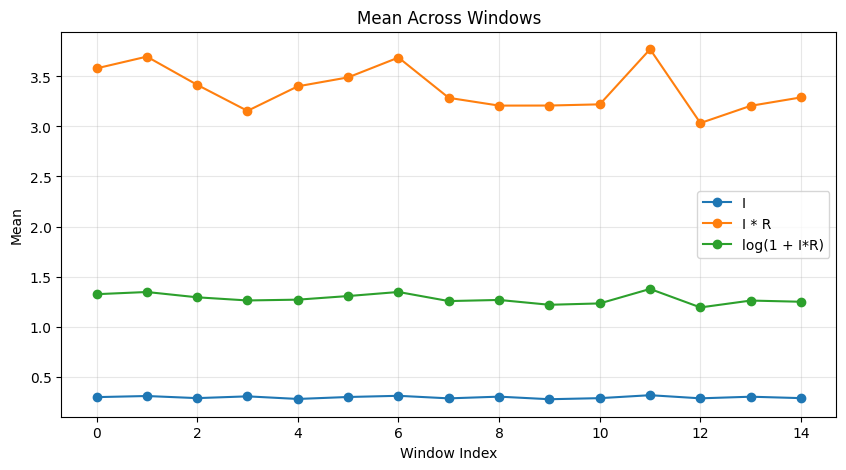

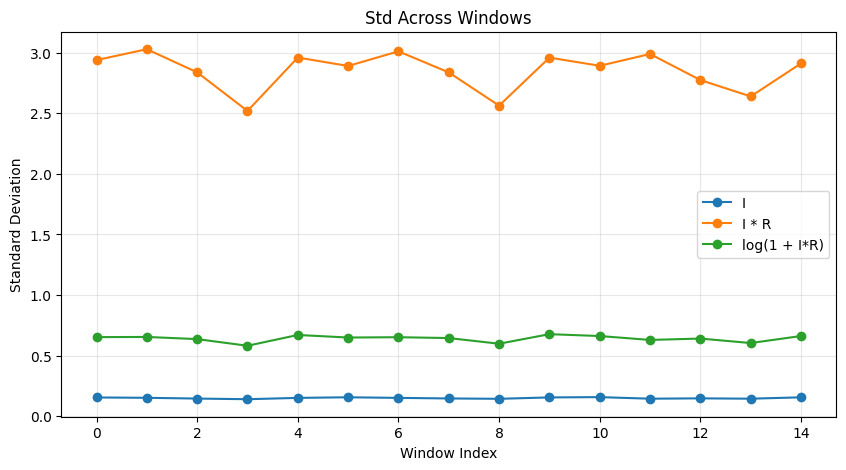

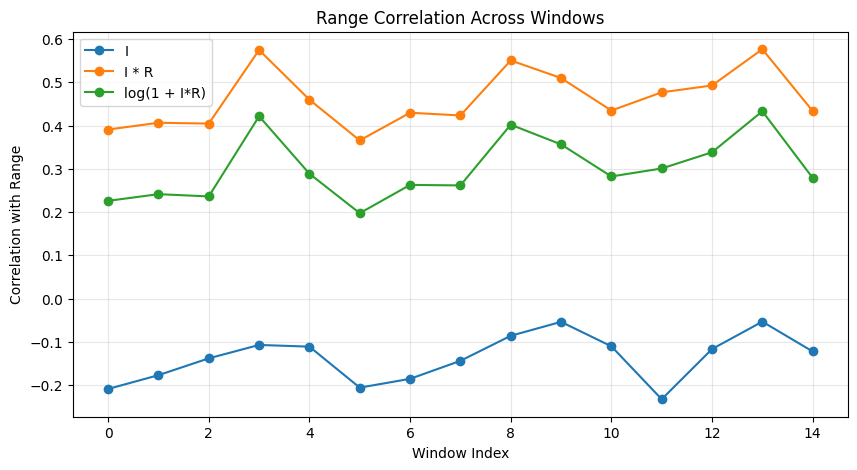

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Window index
x = np.arange(len(metrics_df))

# Mean plot
plt.figure(figsize=(10, 5))
plt.plot(x, metrics_df["I_mean"], marker='o', label="I")
plt.plot(x, metrics_df["IR_mean"], marker='o', label="I * R")
plt.plot(x, metrics_df["logIR_mean"], marker='o', label="log(1 + I*R)")
plt.xlabel("Window Index")
plt.ylabel("Mean")
plt.title("Mean Across Windows")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Std plot
plt.figure(figsize=(10, 5))
plt.plot(x, metrics_df["I_std"], marker='o', label="I")
plt.plot(x, metrics_df["IR_std"], marker='o', label="I * R")
plt.plot(x, metrics_df["logIR_std"], marker='o', label="log(1 + I*R)")
plt.xlabel("Window Index")
plt.ylabel("Standard Deviation")
plt.title("Std Across Windows")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Correlation plot
plt.figure(figsize=(10, 5))
plt.plot(x, metrics_df["I_corr_range"], marker='o', label="I")
plt.plot(x, metrics_df["IR_corr_range"], marker='o', label="I * R")
plt.plot(x, metrics_df["logIR_corr_range"], marker='o', label="log(1 + I*R)")
plt.xlabel("Window Index")
plt.ylabel("Correlation with Range")
plt.title("Range Correlation Across Windows")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Temporal Stability Across Windows

We visualized the variation of signal statistics across all windows for:

- raw intensity $I$,
- primary proxy $I \cdot R$,
- log-scaled proxy $\log(1 + I \cdot R)$.

These plots provide a direct view of temporal stability.

### 1. Mean Across Windows

Observations:

- Raw intensity $I$:
  - remains tightly clustered across all windows,
  - shows minimal variation,
  - confirms low dynamic range but strong stability.

- $I \cdot R$:
  - exhibits moderate variation across windows,
  - noticeable peaks and dips (e.g., around window 11),
  - indicates sensitivity to scene composition.

- $\log(1 + I \cdot R)$:
  - follows the same trend as $I \cdot R$,
  - but with reduced amplitude of variation,
  - demonstrates improved stability through compression.

### 2. Standard Deviation Across Windows

Observations:

- Raw intensity:
  - extremely stable across windows,
  - low variance throughout.

- $I \cdot R$:
  - higher variance compared to intensity,
  - visible fluctuations across windows,
  - reflects expansion of signal spread.

- log-scaled proxy:
  - significantly reduced variance compared to $I \cdot R$,
  - smoother trend across windows,
  - confirms effectiveness of log scaling in stabilizing the signal.

### 3. Range Correlation Across Windows

This is the most important diagnostic.

Observations:

- Raw intensity:
  - consistently weak negative correlation,
  - stable across windows.

- $I \cdot R$:
  - moderate positive correlation overall,
  - **significant spikes in certain windows** (up to ~0.57),
  - indicates window-dependent range dominance.

- log-scaled proxy:
  - consistently lower correlation than $I \cdot R$,
  - reduced spikes,
  - still exhibits variation but remains more controlled.

### 4. Key Insight

The visual analysis confirms that:

> proxy behavior is not uniform across windows.

Even well-behaved proxies:

- exhibit variation depending on scene structure,
- show occasional spikes in range dependence,
- are influenced by local geometry and point distribution.

### 5. Comparative Stability

From the plots:

- Raw intensity is the most stable but least expressive.
- $I \cdot R$ is more expressive but less stable.
- $\log(1 + I \cdot R)$ provides the best trade-off:
  - reduced variance,
  - lower range dependence,
  - smoother temporal behavior.

### 6. Takeaway

This step demonstrates that:

- multi-window evaluation is essential,
- proxy behavior must be analyzed across temporal segments,
- stability is a key criterion for selecting useful features.

These observations prepare the next stage:

> aggregation and quantitative stability metrics across windows.

## Quantify Stability Across Windows

We now move from visual inspection to quantitative stability analysis.

To evaluate how consistent each proxy is across windows, we compute:

### Mean variation
    
$$
\text{Var}(\mu_k)
$$

where $\mu_k$ is the mean of a signal in window $k$.

### Coefficient of Variation (CV)
    
$$
CV = \frac{\text{std}(\mu_k)}{\text{mean}(\mu_k) + \epsilon}
$$

Interpretation:

- low variance → stable signal across windows.
- low CV → consistent relative behavior.
- high CV → sensitivity to scene variation.

This allows us to compare proxies based on **temporal stability**, not just per-window behavior.

This step produces the main quantitative result of this notebook.

In [6]:
stability_summary = []

def compute_stability(name, values):
    values = np.array(values)
    mean_val = np.mean(values)
    std_val = np.std(values)
    var_val = np.var(values)
    cv_val = std_val / (mean_val + 1e-8)
    
    return {
        "proxy": name,
        "mean_of_means": float(mean_val),
        "std_of_means": float(std_val),
        "var_of_means": float(var_val),
        "CV": float(cv_val)
    }

# Extract per-window means
I_means = metrics_df["I_mean"].values
IR_means = metrics_df["IR_mean"].values
logIR_means = metrics_df["logIR_mean"].values

# Compute stability
stability_summary.append(compute_stability("I", I_means))
stability_summary.append(compute_stability("I * R", IR_means))
stability_summary.append(compute_stability("log(1 + I*R)", logIR_means))

# Convert to DataFrame
stability_df = pd.DataFrame(stability_summary)

print("Stability Summary")
print()
print(stability_df)

Stability Summary

          proxy  mean_of_means  std_of_means  var_of_means        CV
0             I       0.293709      0.011757      0.000138  0.040029
1         I * R       3.376979      0.216696      0.046957  0.064169
2  log(1 + I*R)       1.279784      0.049860      0.002486  0.038960


## Conclusion

In this notebook, we extended the proxy analysis from a single-window setting to a multi-window temporal evaluation.

We analyzed the behavior of selected proxy variants across multiple windows of sequence 00, focusing on:

- distribution consistency,
- range dependence,
- and temporal stability.

Key findings:

- Raw intensity remains highly stable across windows but retains limited dynamic range.
- The proxy $I \cdot R$ provides increased expressiveness but exhibits higher variability and occasional spikes in range dependence.
- The log-scaled proxy $\log(1 + I \cdot R)$ achieves the best balance:
  - reduced variance across windows,
  - lower range dependence,
  - and consistent behavior across different temporal segments.

Quantitatively, the log-scaled proxy shows:

- stability comparable to raw intensity,
- while preserving the structural advantages of range-aware transformation.

This demonstrates that:

> proxy performance must be evaluated across multiple windows, as behavior is inherently scene-dependent.

No semantic claims are made at this stage.

This notebook establishes that the selected proxy candidates are:

- not only numerically stable in isolation,
- but also consistent across temporal segments.

These proxies are now ready for:

**multi-window semantic analysis in the next stage.**

---